<a href="https://colab.research.google.com/github/anubhav123456/Deep-Learning/blob/main/7.%20Mathy%20Part/Sigmoid_for_toy_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib.colors as mcolors
import seaborn as sns
sns.set_theme(style="darkgrid")

# Class for Sigmoid Neuron

In [2]:
class SigmoidNeuron:
    def __init__(self):
        self.w = None
        self.b = None

    """
    computes x1*w1 + x2*w2 . . . + b
    """
    def perceptron(self, x):
        return np.dot(x.reshape(1, -1), self.w.T) + self.b

    """
    computes 1 / (1 + e^-x)
    """
    def sigmoid(self, x):
        return 1.0/(1.0 + np.exp(-x))

    def grad_w(self, x, y):
        # compute the predicted value, 1 / (1 + e^perceptron(x))
        # perceptron(x) will give x1*w1+x2*w2 . . . +b
        y_pred = self.sigmoid(self.perceptron(x))
        return (y_pred - y) * y_pred * (1 - y_pred) * x

    def grad_b(self, x, y):
        # compute the predicted value, 1 / (1 + e^perceptron(x))
        # perceptron(x) will give x1*w1+x2*w2 . . . +b
        y_pred = self.sigmoid(self.perceptron(x))
        return (y_pred - y) * y_pred * (1 - y_pred) * 1.0

    def fit(self, X, Y, epochs=1, learning_rate=1, initialize=True):

        # initialize w, b

        if initialize:
            self.w = np.random.randn(1, X.shape[1])
            self.b = 0

        # run for epoch number of times
        for i in range(epochs):
            dw = 0
            db = 0
            # calculate delta_w and delta_b
            for x, y in zip(X, Y):
                dw += self.grad_w(x, y)
                db += self.grad_b(x, y)

            self.w -= learning_rate * dw
            self.b -= learning_rate * db


In [3]:
def plot_sn(X, Y, sn, ax):
  my_cmap = mcolors.LinearSegmentedColormap.from_list("", ["red", "yellow", "green"])
  X1 = np.linspace(-10, 10, 100)
  X2 = np.linspace(-10, 10, 100)
  XX1, XX2 = np.meshgrid(X1, X2)

  YY = np.zeros(XX1.shape)

  for i in range(X2.size):
      for j in range(X1.size):
          val = np.asarray([X1[j], X2[i]])
          YY[i, j] = sn.sigmoid(sn.perceptron(val))
  ax.contourf(XX1, XX2, YY, cmap=my_cmap, alpha=0.6)
  ax.scatter(X[:, 0], X[:, 1], c=Y, cmap=my_cmap)
  ax.plot()

# Fit for toy data

In [4]:
X = np.array([[2.5, 2.5], [4, -1], [1, -4], [-3, 1.25], [-2, -4], [1, 5]])
Y = np.array([1, 1, 1, 0, 0, 0])
X.shape, Y.shape

((6, 2), (6,))

[[-1.16197108 -0.17383118]] [[0.00100423]]


/tmp/ipykernel_1953/1658462961.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  YY[i, j] = sn.sigmoid(sn.perceptron(val))


[[-0.82878946 -0.50849106]] [[0.07627033]]
[[-0.32604433 -0.62661827]] [[0.08027386]]
[[ 0.62941858 -0.65046465]] [[0.12193059]]
[[ 1.05214772 -0.08139634]] [[0.11374925]]
[[ 1.00717336 -0.64730737]] [[0.01008504]]
[[ 1.33393831 -0.12949527]] [[-0.06279573]]
[[ 1.25427126 -0.70633329]] [[-0.16549707]]
[[ 1.52760941 -0.25180394]] [[-0.23920968]]
[[ 1.45427427 -0.72263413]] [[-0.33265933]]
[[ 1.65207006 -0.3919649 ]] [[-0.3911153]]
[[ 1.62050948 -0.64033909]] [[-0.44924692]]
[[ 1.7031009  -0.52779842]] [[-0.48224958]]
[[ 1.71864629 -0.58152428]] [[-0.51344854]]
[[ 1.75155715 -0.57793106]] [[-0.53952406]]
[[ 1.77736158 -0.58890647]] [[-0.56420924]]
[[ 1.80268341 -0.59656143]] [[-0.58709525]]
[[ 1.82653553 -0.6041755 ]] [[-0.6085123]]
[[ 1.8491978  -0.61137875]] [[-0.62860786]]
[[ 1.87077333 -0.61823905]] [[-0.64752318]]


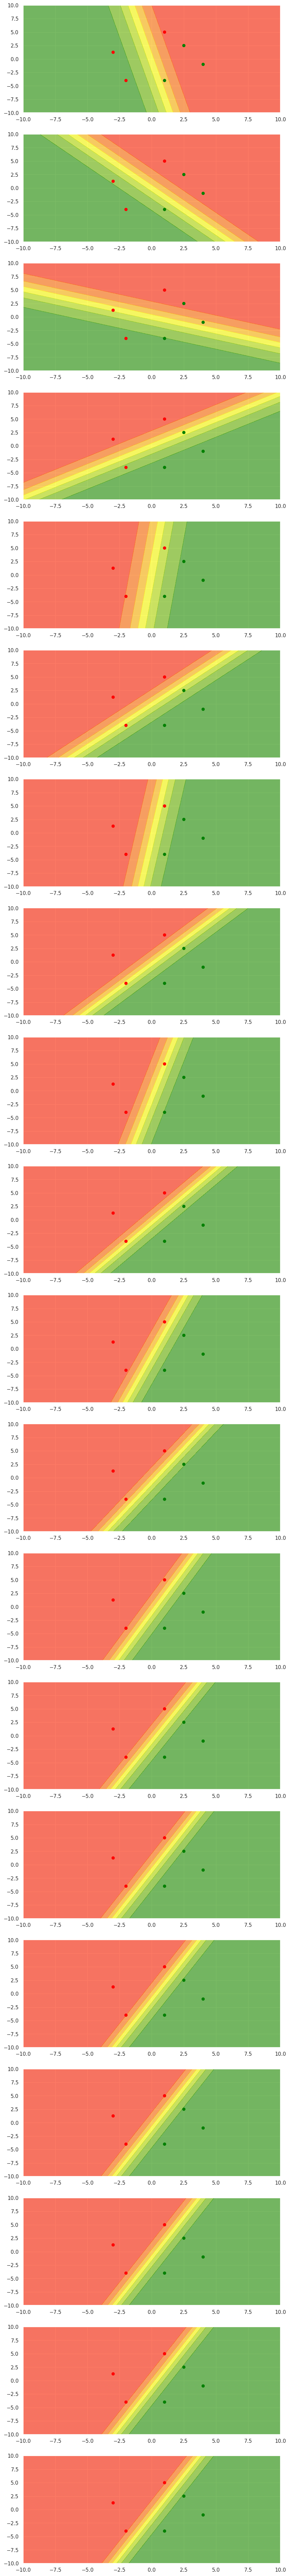

In [5]:
sigmoid_model = SigmoidNeuron()
sigmoid_model.fit(X, Y, 1, 0.01, True)

N = 20
plt.figure(figsize=(10, N*5))
for i in range(N):
    print(sigmoid_model.w, sigmoid_model.b)
    ax = plt.subplot(N, 1, i+1)
    plot_sn(X, Y, sigmoid_model, ax)
    sigmoid_model.fit(X, Y, 1, 0.75, False)
plt.show()
